# Creating a logistic regression to predict customer issues resolution time

## Import the relevant libraries

In [1]:
# import the relevant libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import precision_score, recall_score, f1_score
sns.set()

## Load the data

In [2]:
# load the preprocessed CSV data
data_preprocessed = pd.read_csv('data_preprocessed.csv')

In [3]:
data_preprocessed.head()

,Unnamed: 0,service_type_1,service_type_2,service_type_3,service_type_4,Month Value,Day of the Week,Service_Cost,Distance_to_Service_Center,Customer_Age,Daily_Request_Volume_Avg,Customer_Satisfaction_Index,Customer_Tier,Previous_Requests,Support_Contacts,Issue_Resolution_Time_Hours
0,0,1,0,0,0,12,0,277,4,58,165,72,1,1,3,2.0
1,1,0,0,1,0,11,1,115,34,31,286,44,1,1,2,2.5
2,2,1,0,0,0,2,2,384,48,47,222,96,2,0,2,5.5
3,3,0,0,0,1,10,3,467,18,58,315,67,2,1,0,5.5
4,4,0,1,0,0,10,3,469,40,21,352,53,1,3,3,7.0


## Create the targets

In [4]:
data_preprocessed['Issue_Resolution_Time_Hours'].median()

3.5

In [5]:
targets = np.where(data_preprocessed['Issue_Resolution_Time_Hours'] > 
                   data_preprocessed['Issue_Resolution_Time_Hours'].median(), 1, 0)

In [6]:
targets

array([0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1,
       1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0,
       0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1,
       0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0,
       0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0,
       1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0,
       0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0,
       0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1,
       1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0,
       1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1,
       1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 1,
       0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0,
       1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0,

In [7]:
data_preprocessed['ExcessiveResolutionTime'] = targets

In [8]:
data_preprocessed.head()

,Unnamed: 0,service_type_1,service_type_2,service_type_3,service_type_4,Month Value,Day of the Week,Service_Cost,Distance_to_Service_Center,Customer_Age,Daily_Request_Volume_Avg,Customer_Satisfaction_Index,Customer_Tier,Previous_Requests,Support_Contacts,Issue_Resolution_Time_Hours,ExcessiveResolutionTime
0,0,1,0,0,0,12,0,277,4,58,165,72,1,1,3,2.0,0
1,1,0,0,1,0,11,1,115,34,31,286,44,1,1,2,2.5,0
2,2,1,0,0,0,2,2,384,48,47,222,96,2,0,2,5.5,1
3,3,0,0,0,1,10,3,467,18,58,315,67,2,1,0,5.5,1
4,4,0,1,0,0,10,3,469,40,21,352,53,1,3,3,7.0,1


In [9]:
data_preprocessed=data_preprocessed.drop('Unnamed: 0',axis=1)

In [10]:
data_preprocessed.head()

,service_type_1,service_type_2,service_type_3,service_type_4,Month Value,Day of the Week,Service_Cost,Distance_to_Service_Center,Customer_Age,Daily_Request_Volume_Avg,Customer_Satisfaction_Index,Customer_Tier,Previous_Requests,Support_Contacts,Issue_Resolution_Time_Hours,ExcessiveResolutionTime
0,1,0,0,0,12,0,277,4,58,165,72,1,1,3,2.0,0
1,0,0,1,0,11,1,115,34,31,286,44,1,1,2,2.5,0
2,1,0,0,0,2,2,384,48,47,222,96,2,0,2,5.5,1
3,0,0,0,1,10,3,467,18,58,315,67,2,1,0,5.5,1
4,0,1,0,0,10,3,469,40,21,352,53,1,3,3,7.0,1


In [11]:
#Checking if our target distribution is balance
targets.sum() / targets.shape[0]

0.4957142857142857

In [12]:
#create a checkpoint by dropping the unnecessary variables
data_with_target = data_preprocessed.drop(['Issue_Resolution_Time_Hours',
                                            'Month Value'],axis=1)

In [13]:
data_with_target.head()

,service_type_1,service_type_2,service_type_3,service_type_4,Day of the Week,Service_Cost,Distance_to_Service_Center,Customer_Age,Daily_Request_Volume_Avg,Customer_Satisfaction_Index,Customer_Tier,Previous_Requests,Support_Contacts,ExcessiveResolutionTime
0,1,0,0,0,0,277,4,58,165,72,1,1,3,0
1,0,0,1,0,1,115,34,31,286,44,1,1,2,0
2,1,0,0,0,2,384,48,47,222,96,2,0,2,1
3,0,0,0,1,3,467,18,58,315,67,2,1,0,1
4,0,1,0,0,3,469,40,21,352,53,1,3,3,1


## Select the inputs for the regression

In [14]:
data_with_target.shape

(700, 14)

In [15]:
x = data_with_target.iloc[:,:-1]
y=data_with_target['ExcessiveResolutionTime']

In [16]:
# declare 4 variables for the split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 20)

In [17]:
# check the shape of the train inputs and targets
print (x_train.shape, y_train.shape)
print (x_test.shape, y_test.shape)

(560, 13) (560,)
(140, 13) (140,)


In [18]:
# Scaling input variables

In [19]:
scaler = StandardScaler()

In [20]:
scaler.fit(x_train)

StandardScaler()

In [21]:
x_train_scaled = scaler.transform(x_train)
x_test_scaled = scaler.transform(x_test)

## Logistic Regression

In [22]:
reg = LogisticRegression()
reg.fit(x_train_scaled, y_train)

LogisticRegression()

## Testing

Accuracy: 0.8607142857142858
              precision    recall  f1-score   support

           0       0.86      0.86      0.86       284
           1       0.86      0.86      0.86       276

    accuracy                           0.86       560
   macro avg       0.86      0.86      0.86       560
weighted avg       0.86      0.86      0.86       560

ROC-AUC Score: 0.927064196774852


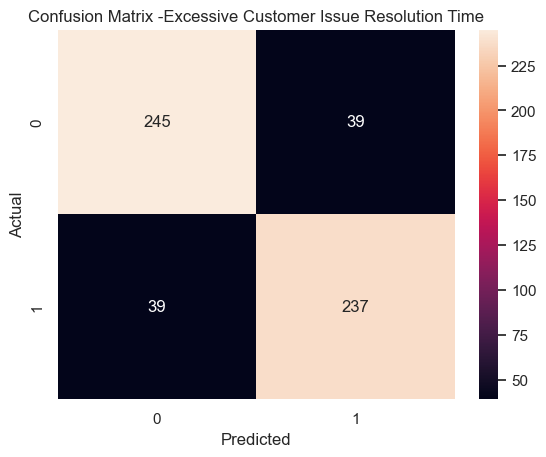

In [23]:
#Testing with the training dataset
y_pred = reg.predict(x_train_scaled)

# Predict probabilities
y_prob = reg.predict_proba(x_train_scaled)[:,1]

print("Accuracy:", accuracy_score(y_train, y_pred))
print(classification_report(y_train, y_pred))

auc = roc_auc_score(y_train, y_prob)
print("ROC-AUC Score:", auc)

cm = confusion_matrix(y_train, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix -Excessive Customer Issue Resolution Time")
plt.show()

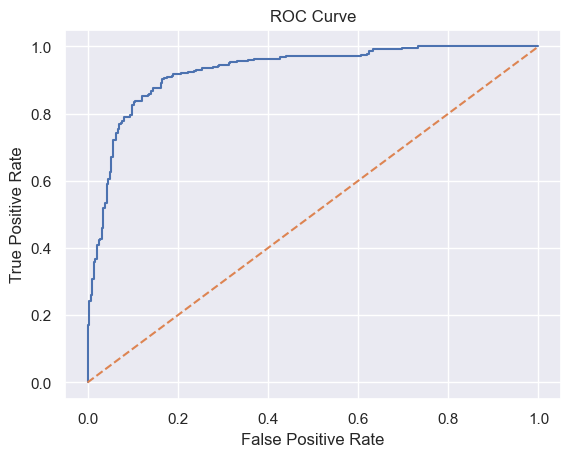

In [24]:
fpr, tpr, thresholds = roc_curve(y_train, y_prob)
plt.plot(fpr, tpr)
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

Accuracy: 0.7928571428571428
              precision    recall  f1-score   support

           0       0.76      0.84      0.80        69
           1       0.83      0.75      0.79        71

    accuracy                           0.79       140
   macro avg       0.80      0.79      0.79       140
weighted avg       0.80      0.79      0.79       140

ROC-AUC Score: 0.9005919575423555


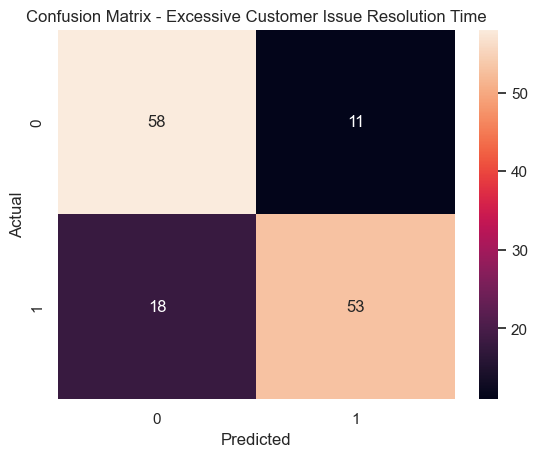

In [25]:
# Testing with testing dataset
y_pred = reg.predict(x_test_scaled)

# Predict probabilities
y_prob = reg.predict_proba(x_test_scaled)[:,1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

auc = roc_auc_score(y_test, y_prob)
print("ROC-AUC Score:", auc)

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Excessive Customer Issue Resolution Time")
plt.show()

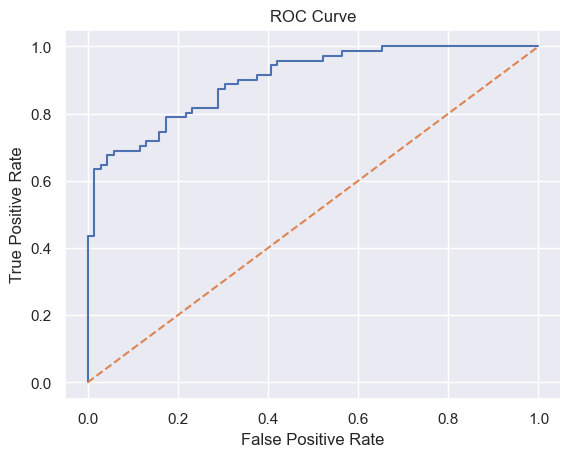

In [26]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.plot(fpr, tpr)
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()